In [1]:
#import et charement du fichier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("donnees/stm_ridership.csv")
df.head()

,date,station,ligne,passengers,temperature,weather
0,2023-01-01,Berri-UQAM,Orange,15200,-5,Snow
1,2023-01-01,Guy-Concordia,Green,9800,-5,Snow
2,2023-01-01,Jean-Talon,Blue,7200,-5,Snow
3,2023-01-02,Berri-UQAM,Orange,18300,-6,Cloudy
4,2023-01-02,Guy-Concordia,Green,11200,-6,Cloudy


In [7]:
#Quelques données statistiques
#informations utiles sur le dataset
df.info()

#Description des données statistiques
df.describe()

#nombre d'éléments vide pas colonne
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         30 non-null     object
 1   station      30 non-null     object
 2   ligne        30 non-null     object
 3   passengers   30 non-null     int64 
 4   temperature  30 non-null     int64 
 5   weather      30 non-null     object
dtypes: int64(2), object(4)
memory usage: 1.5+ KB


,0
date,0
station,0
ligne,0
passengers,0
temperature,0
weather,0


In [12]:
#Nettoyage des données
#conversion date
df['date'] = pd.to_datetime(df['date'])

#Création des variables jour et mois
df['day'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month

df.head()

,date,station,ligne,passengers,temperature,weather,day,month
0,2023-01-01,Berri-UQAM,Orange,15200,-5,Snow,Sunday,1
1,2023-01-01,Guy-Concordia,Green,9800,-5,Snow,Sunday,1
2,2023-01-01,Jean-Talon,Blue,7200,-5,Snow,Sunday,1
3,2023-01-02,Berri-UQAM,Orange,18300,-6,Cloudy,Monday,1
4,2023-01-02,Guy-Concordia,Green,11200,-6,Cloudy,Monday,1


station
Berri-UQAM       19410.0
Guy-Concordia    12200.0
Jean-Talon        9050.0
Name: passengers, dtype: float64


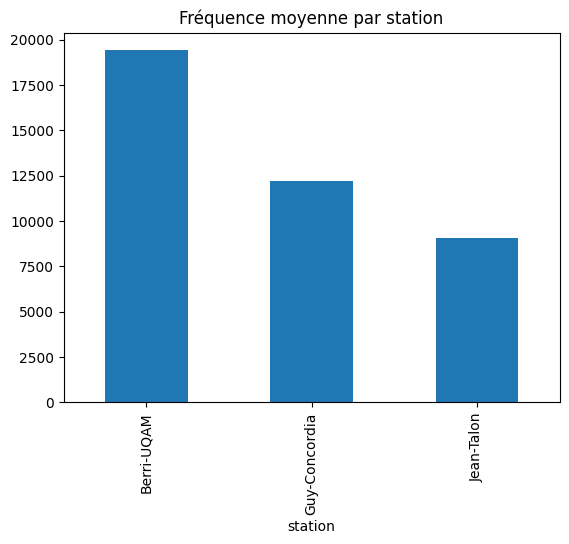

In [14]:
#Fréquence de station
station_usage = df.groupby("station")["passengers"].mean()
print(station_usage)

#Graphe en bar
station_usage.plot(kind='bar')
plt.title("Fréquence moyenne par station")
plt.show()

date
2023-01-01    32200
2023-01-02    37900
2023-01-03    41700
2023-01-04    40100
2023-01-05    43500
2023-01-06    46200
2023-01-07    33800
2023-01-08    31200
2023-01-09    49000
2023-01-10    51000
Name: passengers, dtype: int64


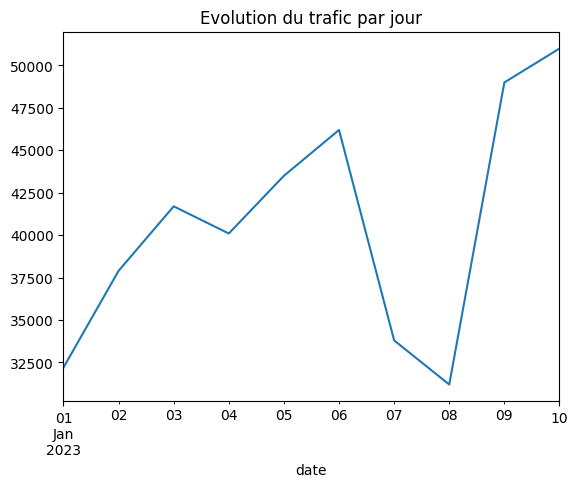

In [19]:
#Evolution du trafic par jours
date_frequence = df.groupby('date')['passengers'].sum()
#print(date_frequence)

#Graphique
date_frequence.plot()
plt.title("Evolution du trafic par jour")
plt.show()

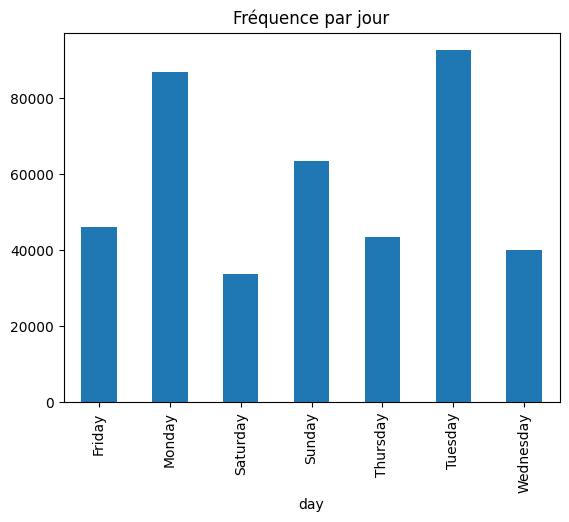

In [20]:
#Evolution semaine et weekend
jour_usage = df.groupby('day')['passengers'].sum()

jour_usage.plot(kind='bar')
plt.title('Fréquence par jour')
plt.show()


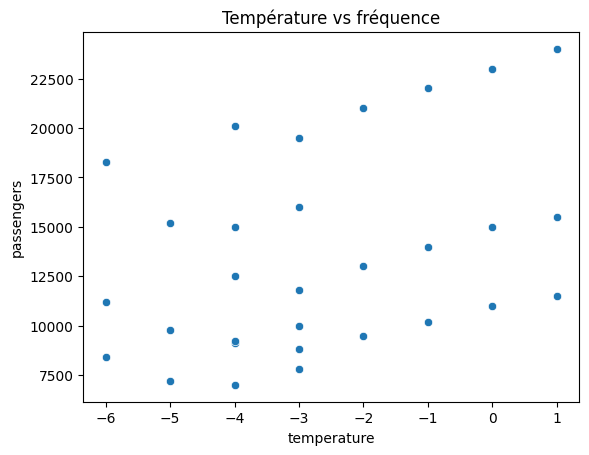

In [22]:
#impact température
sns.scatterplot(x='temperature', y='passengers', data=df)
plt.title("Température vs fréquence")
plt.show()

weather
Clear     15083.333333
Cloudy    12633.333333
Snow      10800.000000
Name: passengers, dtype: float64


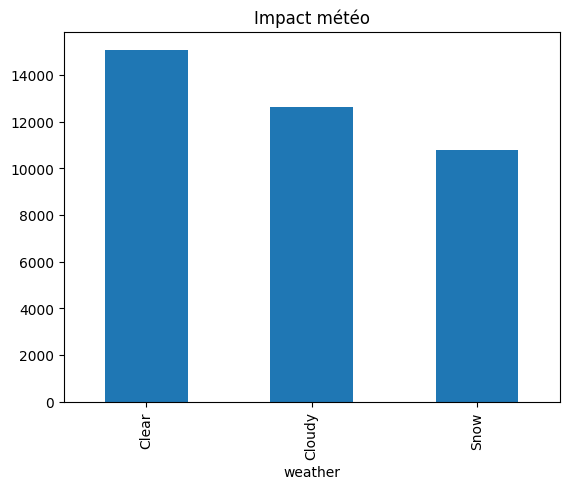

In [23]:
#Météo usage
meteo_usage = df.groupby('weather')['passengers'].mean()
print(meteo_usage)

#graphique a bar
meteo_usage.plot(kind = 'bar')
plt.title('Impact météo')
plt.show()

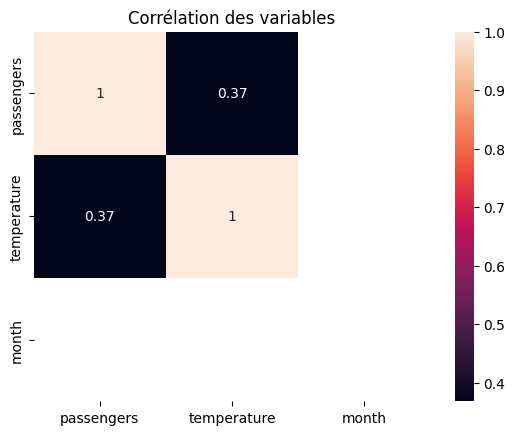

In [24]:
#Correlation
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Corrélation des variables')
plt.show()